In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.util import add_cyclic_point

# load mslp data

In [2]:
ds_mslp = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week5\mslp.mon.mean.nc")
ds_mslp = ds_mslp.sel(time = slice('1979', '2019')) 
ds_mslp.load()

<xarray.Dataset>
Dimensions:    (lat: 73, lon: 144, time: 492, nbnds: 2)
Coordinates:
  * lat        (lat) float32 90.0 87.5 85.0 82.5 ... -82.5 -85.0 -87.5 -90.0
  * lon        (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time       (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) datetime64[ns] 1979-01-01 1979-02-01 ... 2020-01-01
    mslp       (time, lat, lon) float32 1.022e+05 1.022e+05 ... 1.008e+05
Attributes:
    Conventions:    CF-1.0
    title:          Monthly NCEP/DOE Reanalysis 2
    comments:       Data is from \nNCEP/DOE AMIP-II Reanalysis (Reanalysis-2)...
    platform:       Model
    source:         NCEP/DOE AMIP-II Reanalysis (Reanalysis-2) Model
    institution:    National Centers for Environmental Prediction
    dataset_title:  NCEP-DOE AMIP-II Reanalysis
    References:     https://www.psl.noaa.gov/data/gridded/data.ncep.reanalysi...
    source_url:     http://www.cpc.ncep.noaa.gov/products/wesley/reanalysis2/
    history:        created 2002/03 by Hoop (netCDF2.3)\nConverted to chunked...

In [3]:
#make anomaly
mslp_clim = ds_mslp.groupby('time.month').mean(dim = 'time')
mslp_anom = ds_mslp.groupby('time.month') - mslp_clim

In [4]:
mslp_anom

<xarray.Dataset>
Dimensions:  (lat: 73, lon: 144, time: 492)
Coordinates:
  * lat      (lat) float32 90.0 87.5 85.0 82.5 80.0 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    mslp     (time, lat, lon) float32 895.1 895.1 895.1 ... 768.1 768.1 768.1

In [29]:
mslp_anom["mslp"]

<xarray.DataArray 'mslp' (time: 492, lat: 73, lon: 144)>
array([[[ 895.14844  ,  895.14844  ,  895.14844  , ...,  895.14844  ,
          895.14844  ,  895.14844  ],
        [ 943.02344  ,  942.21875  ,  941.2656   , ...,  947.1953   ,
          946.28906  ,  944.34375  ],
        [ 944.46094  ,  945.8281   ,  945.4375   , ...,  944.8281   ,
          944.875    ,  944.4375   ],
        ...,
        [-543.875    , -536.41406  , -527.6797   , ..., -562.90625  ,
         -556.875    , -551.58594  ],
        [-656.125    , -651.3203   , -646.875    , ..., -667.3672   ,
         -664.53906  , -660.4844   ],
        [-383.125    , -383.125    , -383.125    , ..., -383.125    ,
         -383.125    , -383.125    ]],

       [[ 317.97656  ,  317.97656  ,  317.97656  , ...,  317.97656  ,
          317.97656  ,  317.97656  ],
        [ 379.82812  ,  382.78125  ,  384.28906  , ...,  373.3672   ,
          375.17188  ,  377.6328   ],
        [ 457.875    ,  465.71094  ,  472.65625  , ...,  435.53906  ,
          443.17188  ,  450.26562  ],
...
        [ 662.6094   ,  665.6797   ,  670.34375  , ...,  663.6797   ,
          662.02344  ,  662.09375  ],
        [ 701.2422   ,  702.1953   ,  703.3906   , ...,  699.1719   ,
          699.09375  ,  699.8281   ],
        [ 863.4375   ,  863.4375   ,  863.4375   , ...,  863.4375   ,
          863.4375   ,  863.4375   ]],

       [[ 275.34375  ,  275.34375  ,  275.34375  , ...,  275.34375  ,
          275.34375  ,  275.34375  ],
        [ 236.36719  ,  246.34375  ,  255.14844  , ...,  210.28906  ,
          219.19531  ,  227.82812  ],
        [ 116.5625   ,  129.28906  ,  141.36719  , ...,   75.4375   ,
           89.609375 ,  103.36719  ],
        ...,
        [ 678.5156   ,  663.14844  ,  647.2422   , ...,  726.9531   ,
          710.65625  ,  694.6797   ],
        [ 642.2656   ,  633.02344  ,  624.4375   , ...,  668.58594  ,
          659.0703   ,  650.90625  ],
        [ 768.0703   ,  768.0703   ,  768.0703   , ...,  768.0703   ,
          768.0703   ,  768.0703   ]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 90.0 87.5 85.0 82.5 80.0 ... -82.5 -85.0 -87.5 -90.0
  * lon      (lon) float32 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

# load ssp data and calculate nino34 

In [5]:
ds_sst = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week6\sst.mnmean.nc")
#ds_sst = ds_sst.sel(time = slice('1979', '2019')) 
ds_sst.load()

<xarray.Dataset>
Dimensions:    (lat: 89, lon: 180, time: 2030, nbnds: 2)
Coordinates:
  * lat        (lat) float32 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon        (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1854-01-01 1854-02-01 ... 2023-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
    sst        (time, lat, lon) float32 -1.8 -1.8 -1.8 -1.8 ... nan nan nan nan
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    creator_url_original:      https://www.ncei.noaa.gov
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2023-03-04

In [6]:
#make anomaly
sst_clim = ds_sst.sst.groupby('time.month').mean(dim = 'time')
sst_anom = ds_sst.sst.groupby('time.month') - sst_clim

In [30]:
sst_anom

<xarray.DataArray 'sst' (time: 2030, lat: 89, lon: 180)>
array([[[-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        [-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        [-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        ...,
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        [-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        [-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
...
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        [-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        [-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        ...,
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]]],
      dtype=float32)
Coordinates:
  * lat      (lat) float32 88.0 86.0 84.0 82.0 80.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 1854-01-01 1854-02-01 ... 2023-02-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 4 5 6 7 8 9 10 11 12 1 2

In [7]:
#detrend 移掉趨勢 
#區分出variability跟trend。
from scipy.signal import detrend
sst_anom_detrended = xr.apply_ufunc(detrend, sst_anom.fillna(0),
                                    kwargs={'axis': 0}).where(~sst_anom.isnull())

In [8]:
sst_anom_nino34 = sst_anom_detrended.sel(lat = slice(5, -5), lon = slice(190, 240)) 
sst_anom_nino34_mean = sst_anom_nino34.mean(dim = ('lon', 'lat'))
oni34 = sst_anom_nino34_mean.rolling(time = 3, center=True).mean()
ds_oni = oni34.sel(time=slice('1979', '2019'))  

In [31]:
ds_oni

<xarray.DataArray 'sst' (time: 492)>
array([ 3.64065692e-02,  6.10422492e-02,  1.61984026e-01,  1.70094669e-01,
        1.02358282e-01, -5.66177592e-02,  5.08555770e-03,  1.81997418e-01,
        3.87770265e-01,  5.17657936e-01,  5.73489130e-01,  6.47904992e-01,
        5.92190504e-01,  4.39135253e-01,  2.89184213e-01,  2.59172529e-01,
        3.46379638e-01,  3.49849164e-01,  2.12849110e-01,  3.80959138e-02,
       -1.46320909e-02,  7.65385926e-02,  1.59621388e-01,  5.75096309e-02,
       -1.53590918e-01, -3.69609803e-01, -3.73874873e-01, -3.36505502e-01,
       -2.54749537e-01, -2.90474474e-01, -2.61728227e-01, -1.85301751e-01,
       -5.95039725e-02, -1.91008504e-02, -4.40528095e-02,  3.18648294e-02,
        8.23744088e-02,  2.02217370e-01,  2.80456483e-01,  5.00764966e-01,
        6.58095837e-01,  7.12310016e-01,  8.17993581e-01,  1.12536216e+00,
        1.67427564e+00,  2.06986618e+00,  2.27955294e+00,  2.33163691e+00,
        2.30473852e+00,  2.04278231e+00,  1.63264108e+00,  1.30782008e+00,
        1.05809581e+00,  7.09782600e-01,  3.38143080e-01, -2.83224583e-02,
       -3.64330173e-01, -7.07114220e-01, -9.01845396e-01, -8.10435474e-01,
       -4.78896201e-01, -2.99067944e-01, -2.50540584e-01, -4.15984809e-01,
       -5.20082593e-01, -4.61690843e-01, -2.84460813e-01, -1.09675229e-01,
       -1.53553009e-01, -4.65409160e-01, -8.22539449e-01, -1.04914308e+00,
       -9.28210735e-01, -7.34225988e-01, -6.87860191e-01, -7.72563338e-01,
       -7.90211558e-01, -6.45032525e-01, -4.74240869e-01, -4.14868057e-01,
...
       -1.17331564e-01, -3.80321592e-02, -5.60050532e-02, -2.24219084e-01,
       -4.17403758e-01, -4.47377920e-01, -2.01830611e-01,  1.24591574e-01,
        3.15578461e-01,  2.67050415e-01,  1.68363810e-01,  1.76525280e-01,
        3.56558889e-01,  6.14917159e-01,  7.33644187e-01,  6.94866419e-01,
        5.60404360e-01,  4.95568991e-01,  6.07915640e-01,  7.85047293e-01,
        1.04136205e+00,  1.29453039e+00,  1.64425325e+00,  1.97232056e+00,
        2.28558969e+00,  2.54805517e+00,  2.67743945e+00,  2.67849159e+00,
        2.49128151e+00,  2.15654588e+00,  1.65740371e+00,  1.02897072e+00,
        5.05996644e-01,  4.98852730e-02, -2.26880521e-01, -4.19521093e-01,
       -4.95270669e-01, -5.57633042e-01, -5.60022891e-01, -5.25049984e-01,
       -3.36135507e-01, -1.48411378e-01,  1.13311276e-01,  2.76290357e-01,
        3.99611413e-01,  4.19281572e-01,  2.66221702e-01,  2.72691250e-04,
       -2.62429446e-01, -5.32815158e-01, -7.45312810e-01, -9.48505342e-01,
       -9.20409858e-01, -8.43194366e-01, -6.35260284e-01, -4.24478471e-01,
       -1.15584992e-01,  1.01281747e-01,  2.18509480e-01,  3.48154962e-01,
        6.18325591e-01,  8.86686802e-01,  9.98711467e-01,  8.51213634e-01,
        7.58535266e-01,  7.47366130e-01,  7.88646877e-01,  7.50998676e-01,
        6.56201959e-01,  5.67491949e-01,  4.12715375e-01,  2.62695551e-01,
        3.20763528e-01,  4.80514228e-01,  6.16710901e-01,  5.84712684e-01],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

In [10]:
pt_mslp = mslp_anom.sel(lat = 0,lon = 360-180,method = 'nearest')

c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(
c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\xarray\core\indexes.py:234: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  indexer = self.index.get_loc(


In [11]:
pt_mslp

<xarray.Dataset>
Dimensions:  (time: 492)
Coordinates:
    lat      float32 0.0
    lon      float32 180.0
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    mslp     (time) float32 -16.07 20.98 -22.66 16.12 ... 45.41 4.656 75.17

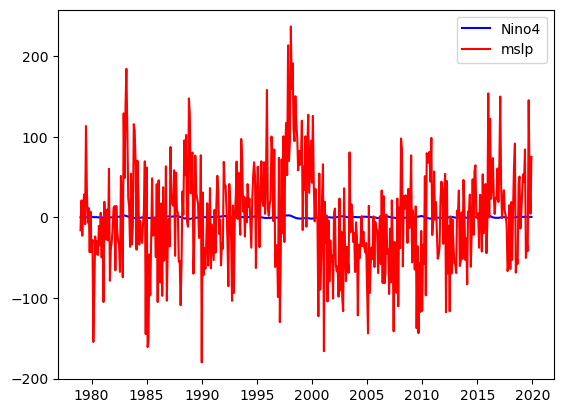

In [12]:
#line plot 
plt.plot(ds_oni['time'],ds_oni,'b')
plt.plot(pt_mslp['time'],pt_mslp["mslp"],'r')
plt.legend(['Nino4','mslp'])

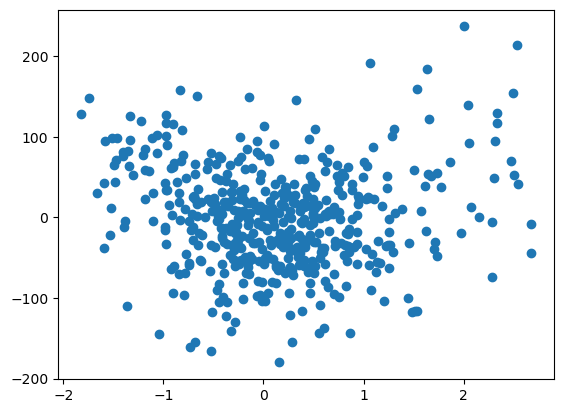

In [13]:
#scatter plot 
plt.scatter(ds_oni,pt_mslp["mslp"])
plt.show()

In [14]:
#numpy correlation function
R = np.corrcoef(ds_oni,pt_mslp["mslp"])
R

array([[ 1.        , -0.01784987],
       [-0.01784987,  1.        ]])

In [15]:
corr = R[0,1]
corr

-0.017849865151236304

In [16]:
#scipy correlation function 
(rvalue, pvalue) =  scipy.stats.pearsonr(ds_oni,pt_mslp['mslp'])
rvalue

-0.01784986515123626

In [17]:
pvalue

0.6928771800205543

Text(1.0, 1.0, 'R= -0.02*')

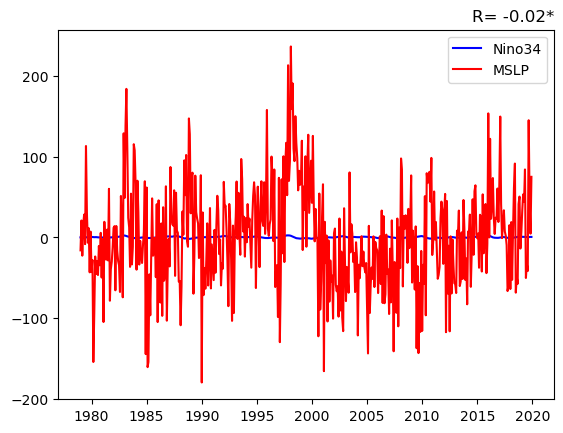

In [18]:
plt.plot(ds_oni['time'],ds_oni,'b')
plt.plot(pt_mslp['time'],pt_mslp['mslp'],'r')
plt.legend(['Nino34','MSLP'])

rvalue_2 = round(rvalue, 2)
stuff_in_string = f"R= {rvalue_2}*"

#print(stuff_in_string)
plt.title(stuff_in_string,loc='right')

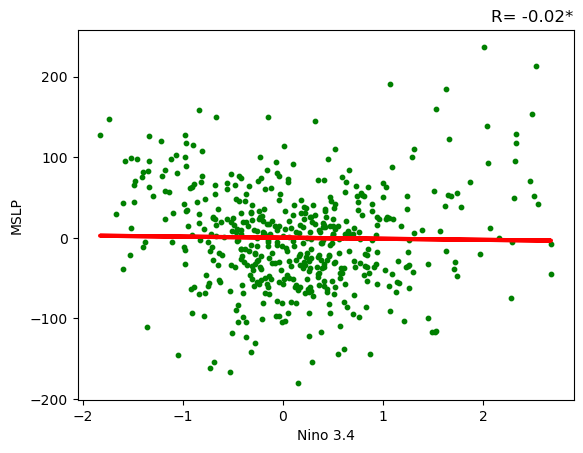

In [19]:
plt.scatter(ds_oni,pt_mslp['mslp'], s = 10, color = "green")
plt.title(stuff_in_string,loc = 'right')

m, b = np.polyfit(ds_oni,pt_mslp['mslp'], 1)
plt.plot(ds_oni, m*ds_oni + b, color = "red",linewidth = 3)
plt.xlabel("Nino 3.4")
plt.ylabel("MSLP")

plt.show()

In [20]:
positive_oni_34 = ((ds_oni>0.5).astype('b').rolling(time = 5, center = True).sum()==5) #選出高於0.5
negative_oni_34 = ((ds_oni<0.5).astype('b').rolling(time = 5, center = True).sum()==5) #選出低於0.5
#positive_oni_34.astype('i').plot(marker='.', label='positive')
#(-negative_oni_34.astype('i')).plot(marker='.', label='negative')
#plt.title('Niño3.4')
#plt.legend()

In [21]:
sst_anom.where(positive_oni_34).mean(dim = 'time')

<xarray.DataArray 'sst' (lat: 89, lon: 180)>
array([[-3.3634112e-04, -3.3034617e-04, -3.1909024e-04, ...,
        -2.4641852e-04, -3.0063579e-04, -3.3882295e-04],
       [-3.2453364e-04, -3.6410682e-04, -3.8877022e-04, ...,
        -9.6256474e-05, -2.1287763e-04, -2.7089092e-04],
       [-7.0089318e-06, -1.1033753e-04, -1.7490014e-04, ...,
        -5.7300891e-05, -3.6752368e-05, -1.6613179e-05],
       ...,
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan]], dtype=float32)
Coordinates:
  * lat      (lat) float32 88.0 86.0 84.0 82.0 80.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0

In [22]:
sst_anom.where(negative_oni_34).mean(dim='time')

<xarray.DataArray 'sst' (lat: 89, lon: 180)>
array([[1.2493492e-03, 1.2094867e-03, 1.1618779e-03, ..., 9.3913887e-04,
        1.1387696e-03, 1.2763273e-03],
       [1.1802249e-03, 1.3209564e-03, 1.4066469e-03, ..., 3.4796679e-04,
        7.7255996e-04, 9.8561600e-04],
       [3.2920565e-05, 3.9893025e-04, 6.3259545e-04, ..., 2.7503507e-04,
        1.7553590e-04, 7.9004996e-05],
       ...,
       [          nan,           nan,           nan, ...,           nan,
                  nan,           nan],
       [          nan,           nan,           nan, ...,           nan,
                  nan,           nan],
       [          nan,           nan,           nan, ...,           nan,
                  nan,           nan]], dtype=float32)
Coordinates:
  * lat      (lat) float32 88.0 86.0 84.0 82.0 80.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0

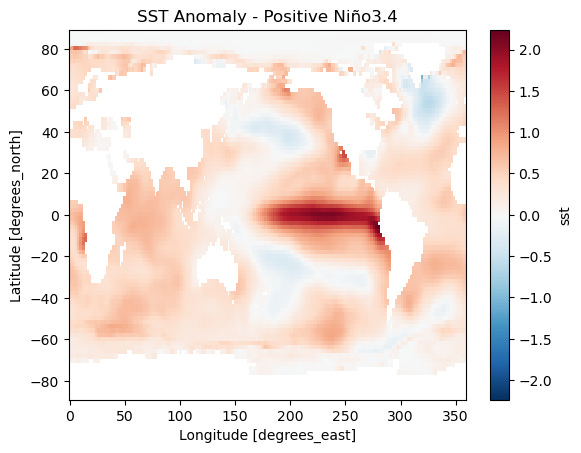

In [21]:
#sst_anom.where(positive_oni_34).mean(dim='time').plot()
#plt.title('SST Anomaly - Positive Niño3.4');

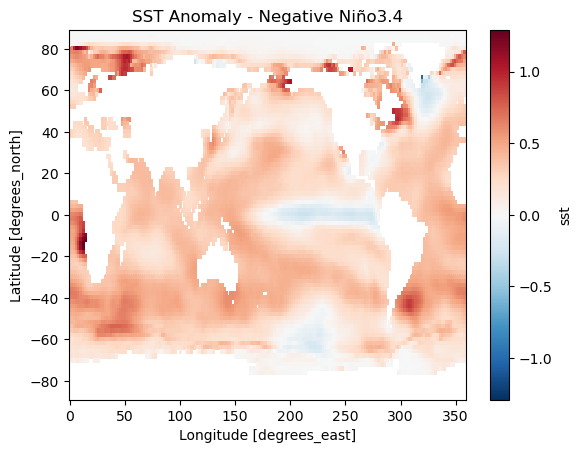

In [22]:
#sst_anom.where(negative_oni_34).mean(dim='time').plot()
#plt.title('SST Anomaly - Negative Niño3.4');

In [25]:
mean1 = sst_anom.where(positive_oni_34).mean(dim='time')  #正年所有年
mean2 = sst_anom.mean(dim='time')               #所有年

#mean1.plot()
#mean2.plot()

In [75]:
std1 = sst_anom.where(positive_oni_34).std(dim='time')
#std1.plot()
std2 = sst_anom.std(dim='time')
#std2.plot()

In [77]:
nobs1 = np.count_nonzero(positive_oni_34)   #選出不等於0的個數
#nobs1
nobs2 = len(oni34) #全部年的各數
#nobs2

In [78]:
modified_std1 = np.sqrt(np.float32(nobs1)/np.float32(nobs1-1)) * std1
#modified_std1
modified_std2 = np.sqrt(np.float32(nobs2)/np.float32(nobs2-1)) * std2
#modified_std2

In [79]:
import scipy.stats as stats
from scipy.stats import ttest_ind, ttest_ind_from_stats

In [80]:
(statistic, pvalue) = stats.ttest_ind_from_stats(mean1=mean1, std1=modified_std1, nobs1=nobs1, mean2=mean2, std2=modified_std2, nobs2=nobs2 )
print(pvalue)

[[0.68749464 0.70325345 0.7151509  ... 0.6727444  0.6738829  0.67503434]
 [0.7083986  0.71670353 0.7248981  ... 0.7249276  0.7145441  0.70672256]
 [0.79183584 0.7249228  0.7249096  ... 0.79050976 0.79183125 0.79184973]
 ...
 [       nan        nan        nan ...        nan        nan        nan]
 [       nan        nan        nan ...        nan        nan        nan]
 [       nan        nan        nan ...        nan        nan        nan]]


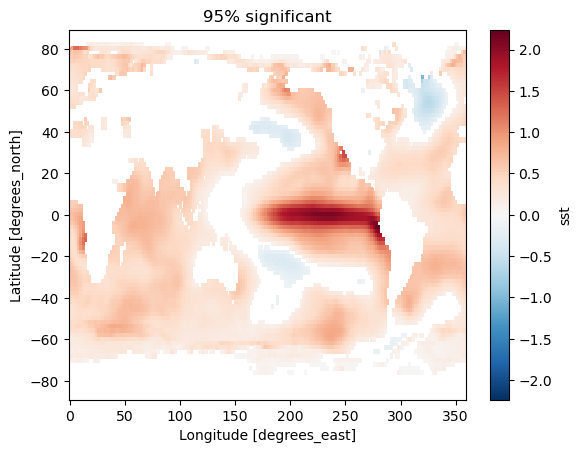

In [81]:
alpha = 0.05 #95信心水準
mean1_sig=mean1.where(pvalue <= alpha) #只畫有過檢定的地方，沒過的就濾掉
mean1_sig.plot()
plt.title('95% significant');

# positive nino34 with no significant test

In [32]:
#Method I: xarray
r_map_pos = xr.corr(ds_oni,sst_anom.where(positive_oni_34),dim = 'time')
r_map_pos


<xarray.DataArray 'sst' (lat: 89, lon: 180)>
array([[-0.07727245, -0.07093856, -0.06662256, ..., -0.08486273,
        -0.08381907, -0.08289788],
       [-0.06891852, -0.06598391, -0.06317424, ..., -0.06317424,
        -0.06673986, -0.06952245],
       [-0.07322769, -0.06317422, -0.06317424, ..., -0.07327508,
        -0.07322764, -0.07322765],
       ...,
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]])
Coordinates:
  * lat      (lat) float32 88.0 86.0 84.0 82.0 80.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0

In [29]:
r_map_pos_test = xr.corr(ds_oni,sst_anom.where(positive_oni_34).mean("time"),dim = 'time')

POSITIVE

Text(0.5, 1.0, 'Correlation between Nino3.4 and Precipitation Anomalie')

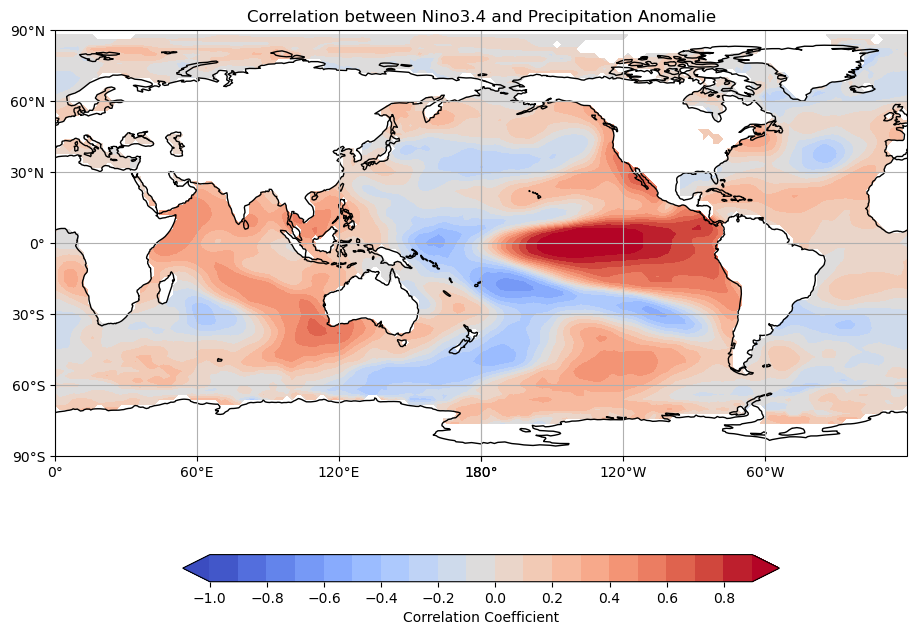

In [34]:
clevs = np.arange(-1.,1.,0.1)

fig = plt.figure(figsize = (11,8.5))

# Set the axes using the specified map projection
ax = plt.axes(projection = ccrs.PlateCarree(central_longitude = 180))

# Add cyclic point
data = r_map_pos
data,lon = add_cyclic_point(r_map_pos,coord = sst_anom.where(positive_oni_34)['lon'])

# Make a filled contour plot
cs = ax.contourf(lon,sst_anom.where(positive_oni_34).mean(dim='time')['lat'],
            data,clevs,
            transform = ccrs.PlateCarree(),
            cmap = 'coolwarm',extend = 'both')

# Add coastlines
ax.coastlines()

# Add gridlines
ax.gridlines()

# Define the xticks for longtitude 
ax.set_xticks(np.arange(-180,181,60),crs = ccrs.PlateCarree())
lon_formatter=cticker.LongitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)

# Define ytick for latitude
ax.set_yticks(np.arange(-90,91,30),crs = ccrs.PlateCarree())
lat_formatter = cticker.LatitudeFormatter()
ax.yaxis.set_major_formatter(lat_formatter)

# Call colorbar
cbar = plt.colorbar(cs,orientation = 'horizontal',shrink = 0.7,
                 label = 'Correlation Coefficient')

# Add title
plt.title('Correlation between Nino3.4 and Precipitation Anomalie')

# positive nino34 with significant test

In [92]:
#Method II: scipy
from scipy.stats import pearsonr

In [97]:
a = sst_anom.where(positive_oni_34).mean(dim='time')

In [107]:
nx = len(sst_anom.where(positive_oni_34)['lon'])
ny = len(sst_anom.where(positive_oni_34)['lat'])

p_array = np.zeros((ny,nx))
r_array = np.zeros((ny,nx))

for i in range(nx):
    for j in range(ny):
        r,p = pearsonr(ds_oni,r_map_pos[:,j,i])
        r_array[j,i]=r
        p_array[j,i]=p
r_array.shape

IndexError: too many indices

In [23]:
sst_anom.where(negative_oni_34).mean("time")

<xarray.DataArray 'sst' (lat: 89, lon: 180)>
array([[1.2493492e-03, 1.2094867e-03, 1.1618779e-03, ..., 9.3913887e-04,
        1.1387696e-03, 1.2763273e-03],
       [1.1802249e-03, 1.3209564e-03, 1.4066469e-03, ..., 3.4796679e-04,
        7.7255996e-04, 9.8561600e-04],
       [3.2920565e-05, 3.9893025e-04, 6.3259545e-04, ..., 2.7503507e-04,
        1.7553590e-04, 7.9004996e-05],
       ...,
       [          nan,           nan,           nan, ...,           nan,
                  nan,           nan],
       [          nan,           nan,           nan, ...,           nan,
                  nan,           nan],
       [          nan,           nan,           nan, ...,           nan,
                  nan,           nan]], dtype=float32)
Coordinates:
  * lat      (lat) float32 88.0 86.0 84.0 82.0 80.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0

In [27]:
sst_anom

<xarray.DataArray 'sst' (time: 2030, lat: 89, lon: 180)>
array([[[-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        [-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        [-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        ...,
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        [-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        [-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
...
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]],

       [[-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        [-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        [-1.19209290e-07, -1.19209290e-07, -1.19209290e-07, ...,
         -1.19209290e-07, -1.19209290e-07, -1.19209290e-07],
        ...,
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]]],
      dtype=float32)
Coordinates:
  * lat      (lat) float32 88.0 86.0 84.0 82.0 80.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 1854-01-01 1854-02-01 ... 2023-02-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 4 5 6 7 8 9 10 11 12 1 2

In [24]:
#Method I: xarray
r_map_neg = xr.corr(ds_oni,sst_anom.where(negative_oni_34),dim = 'time')
r_map_neg

<xarray.DataArray 'sst' (lat: 89, lon: 180)>
array([[-0.0158448 , -0.01488939, -0.01439438, ..., -0.01721082,
        -0.01695959, -0.01672119],
       [-0.01450707, -0.01422161, -0.01393352, ..., -0.01393432,
        -0.01429621, -0.01456451],
       [-0.01324618, -0.01393419, -0.01393384, ..., -0.01325352,
        -0.01324613, -0.01324631],
       ...,
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan],
       [        nan,         nan,         nan, ...,         nan,
                nan,         nan]])
Coordinates:
  * lat      (lat) float32 88.0 86.0 84.0 82.0 80.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0

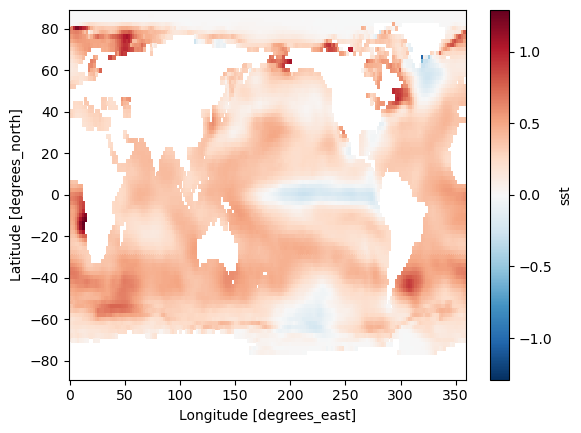

In [35]:
sst_anom.where(negative_oni_34).mean(dim='time').plot()

c:\Users\USER\anaconda3\envs\UMCC_111_1\lib\site-packages\cartopy\mpl\gridliner.py:451: UserWarning: The .xlabels_top attribute is deprecated. Please use .top_labels to toggle visibility instead.
  warnings.warn('The .xlabels_top attribute is deprecated. Please '


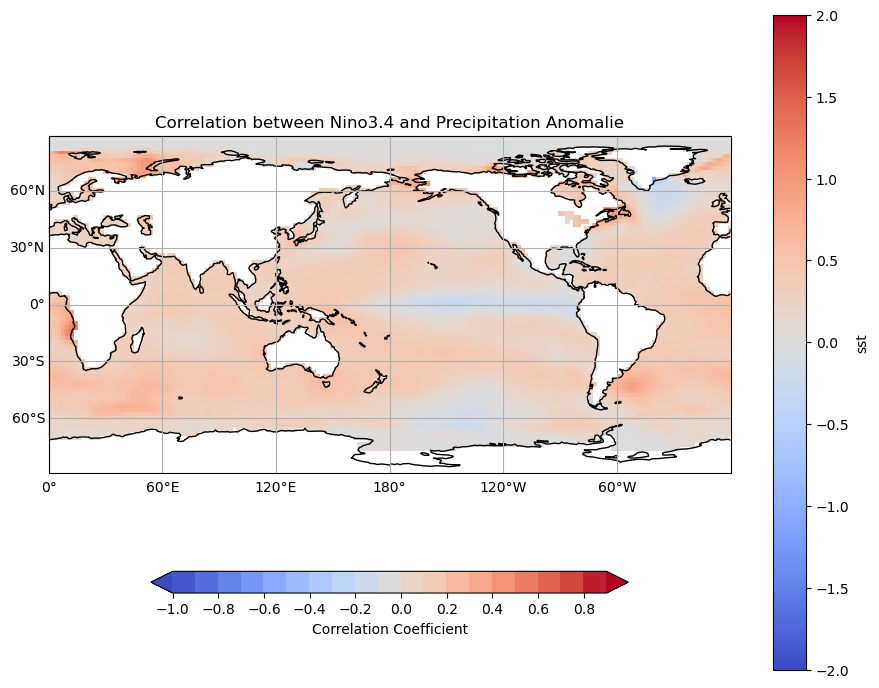

In [50]:
fig = plt.figure(figsize = (11,8.5))
cm = 180
# 111 means 1 row, 1 col and index 1
ax = fig.add_subplot(111, projection = ccrs.PlateCarree(central_longitude = cm))


lats = sst_anom.where(negative_oni_34).mean(dim = 'time')['lat']
lons = sst_anom.where(negative_oni_34).mean(dim = 'time')['lon']
#clevels = [-2,-1.3,-0.2,0.2,1.3,2]
#clevels = np.arange(-2, 2, 0.2)


sst_anom.where(negative_oni_34).mean(dim='time').plot(ax = ax, vmax = 2, cmap = 'coolwarm',transform = ccrs.PlateCarree())
#ds['sst'].plot(ax=ax, levels=clevels, cmap='PiYG', transform=ccrs.PlateCarree())

cbar = plt.colorbar(cs,orientation = 'horizontal',shrink = 0.7, label = 'Correlation Coefficient')

ax.coastlines()
ax.set_title("Correlation between Nino3.4 and Precipitation Anomalie")
ax.gridlines()
#ax.stock_img() 

#ax.gridlines(draw_labels=True)
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,linewidth=2, color='gray', alpha=0.5, linestyle='--')
gl.xlabels_top = False
#gl.ylabels_left = False
gl.xlines = False
gl.ylines = False




NEGATIVE

Text(0.5, 1.0, 'Correlation between Nino3.4 and Precipitation Anomalie')

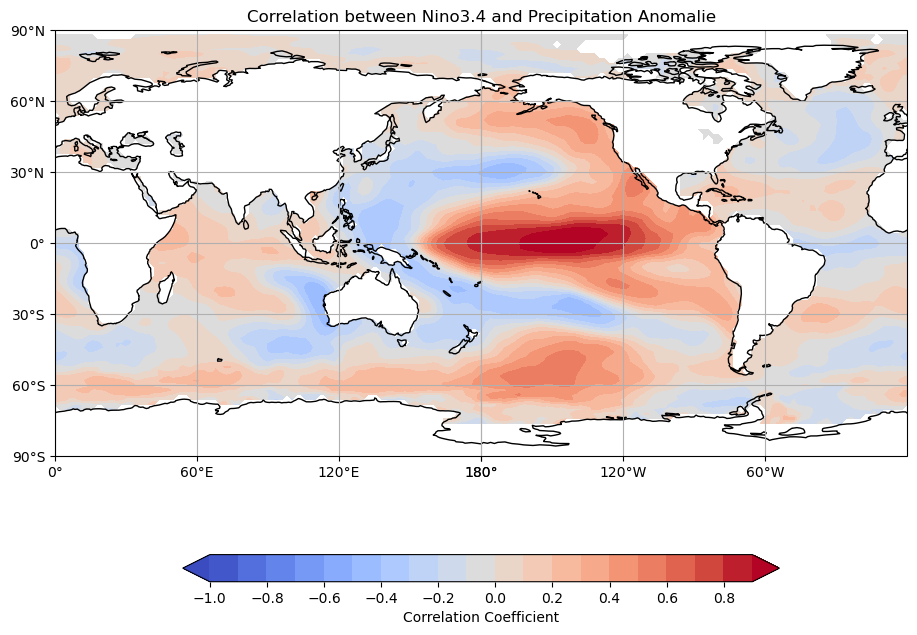

In [25]:
clevs = np.arange(-1.,1.,0.1)

fig = plt.figure(figsize = (11,8.5))

# Set the axes using the specified map projection
ax = plt.axes(projection = ccrs.PlateCarree(central_longitude = 180))

# Add cyclic point
data = r_map_neg
data,lon = add_cyclic_point(r_map_neg,coord = sst_anom.where(negative_oni_34).mean(dim='time')['lon'])

# Make a filled contour plot
cs = ax.contourf(lon,sst_anom.where(negative_oni_34).mean(dim='time')['lat'],
            data,clevs,
            transform = ccrs.PlateCarree(),
            cmap = 'coolwarm',extend = 'both')

# Add coastlines
ax.coastlines()

# Add gridlines
ax.gridlines()

# Define the xticks for longtitude 
ax.set_xticks(np.arange(-180,181,60),crs = ccrs.PlateCarree())
lon_formatter = cticker.LongitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)

# Define ytick for latitude
ax.set_yticks(np.arange(-90,91,30),crs = ccrs.PlateCarree())
lat_formatter = cticker.LatitudeFormatter()
ax.yaxis.set_major_formatter(lat_formatter)

# Call colorbar
cbar = plt.colorbar(cs,orientation = 'horizontal',shrink = 0.7,
                 label = 'Correlation Coefficient')

# Add title
plt.title('Correlation between Nino3.4 and Precipitation Anomalie')

In [71]:
#Method I: xarray
r_map_try = xr.corr(sst_anom,sst_anom.where(negative_oni_34),dim = 'time')
r_map_try

<xarray.DataArray 'sst' (lat: 89, lon: 180)>
array([[1.00000003, 1.00000005, 1.00000009, ..., 1.00000008, 1.00000008,
        0.99999994],
       [0.99999995, 1.00000009, 0.9999999 , ..., 1.00000007, 0.99999991,
        0.99999999],
       [0.99999993, 0.99999997, 1.        , ..., 0.99999994, 1.        ,
        0.99999999],
       ...,
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]])
Coordinates:
  * lat      (lat) float32 88.0 86.0 84.0 82.0 80.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0

Text(0.5, 1.0, 'Correlation between Nino3.4 and Precipitation Anomalie')

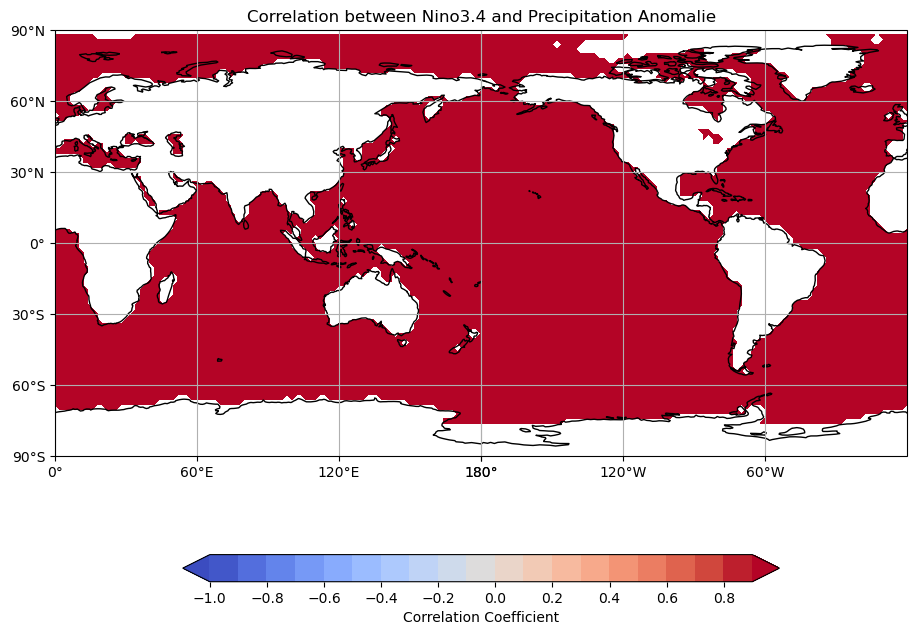

In [72]:
clevs = np.arange(-1.,1.,0.1)

fig = plt.figure(figsize = (11,8.5))

# Set the axes using the specified map projection
ax = plt.axes(projection = ccrs.PlateCarree(central_longitude = 180))

# Add cyclic point
data = r_map_try
data,lon = add_cyclic_point(r_map_try,coord = sst_anom.where(negative_oni_34).mean(dim='time')['lon'])

# Make a filled contour plot
cs = ax.contourf(lon,sst_anom.where(negative_oni_34).mean(dim='time')['lat'],
            data,clevs,
            transform = ccrs.PlateCarree(),
            cmap = 'coolwarm',extend = 'both')

# Add coastlines
ax.coastlines()

# Add gridlines
ax.gridlines()

# Define the xticks for longtitude 
ax.set_xticks(np.arange(-180,181,60),crs = ccrs.PlateCarree())
lon_formatter = cticker.LongitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)

# Define ytick for latitude
ax.set_yticks(np.arange(-90,91,30),crs = ccrs.PlateCarree())
lat_formatter = cticker.LatitudeFormatter()
ax.yaxis.set_major_formatter(lat_formatter)

# Call colorbar
cbar = plt.colorbar(cs,orientation = 'horizontal',shrink = 0.7,
                 label = 'Correlation Coefficient')

# Add title
plt.title('Correlation between Nino3.4 and Precipitation Anomalie')